# Analyzing Gene-to-GP Cosine Similarity

This tutorial demonstrates how to identify and visualize genes that are most relevant to specific gene programs (GPs) in different cell types. This analysis helps answer:

1. **Which genes drive GP activity?** - Identify genes with high similarity to a GP's embedding
2. **How do genes differ between cell types?** - Find genes that are differentially associated with a GP across cell types


## What is Gene-to-GP Cosine Similarity?

For each gene program, we compute the **cosine similarity** between:
- Each gene's embedding (learned representation in the GP space)
- The GP's embedding itself

**High similarity** = Gene is strongly aligned with/represented by that GP
**Low similarity** = Gene is not important for that GP

This reveals which genes are most important for each gene program in eahc cell type

## Prerequisites
- Completed model training and gene embedding analysis
- Gene-to-GP cosine similarities computed and saved in `output_global/gene_embeddings_analysis/`

In [1]:
import scanpy as sc
import pandas as pd
from gplearner.Evaluate.downstream import calculate_gene_significance, plot_top_genes
import numpy as np
import anndata as ad
import os

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42  # Use TrueType fonts (editable text in PDFs)

## 2. Load Gene-to-GP Cosine Similarity Data

### 2.1 Define Loading Function

The gene-to-GP similarity data is stored as AnnData objects where:
- **Observations (rows)**: Individual cells
- **Variables (columns)**: Genes
- **Data matrix (X)**: Cosine similarity between each gene and the GP for each cell

Here, we are examining FOXO3 which was identified as being important in cDC2 in the previous step, but you can replace with any GP of interest. 

In [ ]:
def load_adata(run):
    """
    Load gene-to-GP cosine similarity data for all data splits.
    
    Parameters:
    -----------
    run : str
        Run identifier (e.g., 'run_1', 'run_2', 'run_3') for multi-run averaging
        Note: Currently not used in file path, but kept for multi-run compatibility
        
    Returns:
    --------
    adata : AnnData
        Concatenated data with gene-to-GP similarities across all splits
    """
    holder = []
    base_path = 'path/to/your/folder/07_tutorial_zeng/output_global/gene_embeddings_analysis'
    
    # Load data from train, validation, and test splits
    for t in ['train', 'val', 'test']:
        # NOTE: This path is specific to GP_FOXO3 analysis
        # To analyze other GPs, modify this path (e.g., GP_GATA1_dendritic_cells/)
        filename_1 = f'GP_FOXO3_dendritic_cells/gene_to_GP_FOXO3_cosine_similarity_{t}_set.h5ad'
        
        holder.append(
            sc.read_h5ad(os.path.join(base_path, filename_1))
        )
    
    # Concatenate all splits
    adata = ad.concat(holder)    
    
    return adata

**Multi-run Averaging Option**:
- In the main Tripso paper, we train the model 3 times with different seeds
- Load each run and average the cosine similarities
- This reduces stochastic noise from training

**Single-run Option** (used here):
- Faster for exploratory analysis
- Suitable for tutorials and initial investigation

In [4]:
# Load data from a single run (tutorial mode)
run1 = load_adata('run_1')

# For publication: load multiple runs and average (commented out)
# run2 = load_adata('run_2')
# run3 = load_adata('run_3')

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


### Optionally Average Multiple Runs

If you have multiple training runs, average the similarity scores for increased robustness.

In [5]:
# Option 1: Average across multiple runs (recommended for publication)
# adata = sc.AnnData(
#     X = (run1.X + run2.X + run3.X)/3,  # Average similarity scores
#     obs = run1.obs,                     # Use metadata from run1 (same across runs)
#     var = run1.var                      # Gene names (same across runs)
# )

# Option 2: Use single run (tutorial mode)
adata = run1
adata

AnnData object with n_obs × n_vars = 16668 × 196
    obs: 'length', 'AuthorCellType', 'AuthorCellType_Broad', 'cell_type', 'Sorting', 'Study', 'donor', 'sex', 'development_stage', 'age_group', 'n_counts', 'idx', 'batch_key', 'cell_type_id', 'age_group_id', 'batch_key_id'

### 3. Comparison: pDC vs. cDC

**Goal**: Identify genes that are differentially similar to GP_FOXO3 between plasmacytoid DCs and conventional DC.

**Parameters**:
- `obs_value_ref="cDC"`: Reference population (baseline)
- `obs_value_query="pDC"`: Query population (comparison)
- `adata_gene_threshold=0.9`: drop genes which are 0 in >90% of cells

**Interpretation**:
- Positive values = Genes with higher GP_FOXO3 similarity in pDC
- Negative values = Genes with higher GP_FOXO3 similarity in cDC2


In [6]:
# Calculate differential gene-to-GP similarity between pDC and cDC2
res = calculate_gene_significance(
    adata,
    obs_col="AuthorCellType_Broad",           # Column containing cell type annotations
    obs_value_ref="cDC",           # Reference cell type (baseline)
    obs_value_query="pDC",          # Query cell type (comparison)
    adata_gene_threshold=0.9,       # Filter: keep genes detected in ≥90% of cells
)

### Visualize Top Differentially Similar Genes (pDC vs. cDC2)

Create a bar plot showing the top genes with differential GP_FOXO3 similarity between pDC and cDC2.

**Visualization Parameters**:
- `topn=10`: Show top 10 genes
- `show_significance=False`: Don't add stars for genes reaching statistically significance
- `color_scheme='significance'`: Color by significance (-log10 adjusted p-value)
- `significance_palette`: Custom colors for significance (darker = more significant)
- `palette_as_gradient=True`: Use significance color gradient rather than color blocks


/nfs/team361/mm58/gplearner/gplearner/Evaluate/downstream.py:2196: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 0].set_yticklabels(yticklabels)
/nfs/team361/mm58/gplearner/gplearner/Evaluate/downstream.py:2281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 1].set_yticklabels(yticklabels)


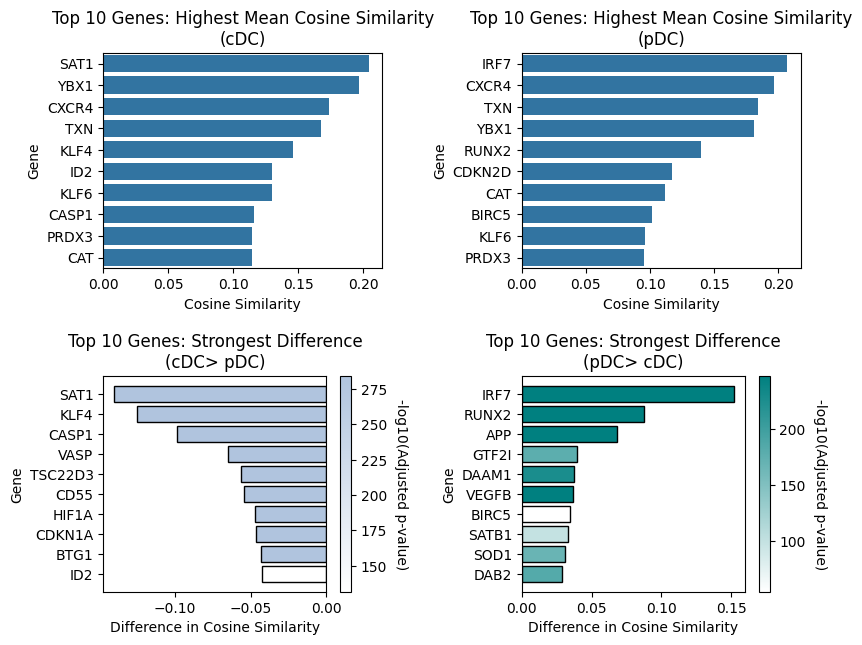

In [7]:
# Visualize top genes differentially associated with GP_FOXO3 in pDC vs. cDC2
plot_top_genes(
    res,
    obs_value_ref="cDC",
    obs_value_query="pDC",
    show_significance=False,                        # Hide significance stars
    color_scheme='significance',                    # Color by effect size
    significance_palette=['lightsteelblue', 'teal'], # Color gradient
    palette_as_gradient=True,                       # Smooth gradient
    topn=10,                                        # Display top 10 genes
    figsize=(9, 7),
    # save_to='GP_FOXO3_pDC_vs_cDC2.pdf'            # Uncomment to save figure
)